# First lensing simulation

This notebook is the step-by-step version of `scripts/first_lensing_simulation.py`. It builds a simple SIE lens, lenses a Sersic source, adds lens-galaxy light, plots the main image planes, and saves the arrays plus a summary figure. This notebook is by Prof. Giulia Despali — not covered by repository MIT license.

## Imports and paths

Run the notebook from either the project root or the `notebooks/` directory. Outputs are written to the project-level `outputs/` folder.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM

from pyLensLib.compositeModel import compositeModel
from pyLensLib.nfwell import nfwell
from pyLensLib.sersic import sersic
from pyLensLib.sie import sie

%matplotlib inline

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

outdir = project_root / "outputs"
outdir.mkdir(exist_ok=True)

outdir

PosixPath('/home/sabrina-n/tesi-triennale/outputs')

## Cosmology and image grid

In [ ]:
co = FlatLambdaCDM(H0=70.0, Om0=0.3)
zl = 0.5 # 0.5, 0.2 
zs = 2.0 # 0.5: 2 o 1.5 , 0.2: 1

fov = 6.0 # field of view, quanto è grande l'immagine, il plot, in arcsec 
npix = 220 # numero di pixel 
theta = np.linspace(-fov / 2.0, fov / 2.0, npix)
extent = [-fov / 2.0, fov / 2.0, -fov / 2.0, fov / 2.0]

print(f"Grid: {npix} x {npix} pixels over {fov:.1f} arcsec")
print(f"Lens redshift: {zl:.2f}; source redshift: {zs:.2f}")

Grid: 220 x 220 pixels over 6.0 arcsec
Lens redshift: 0.50; source redshift: 2.00


## Define the SIE lens

In [ ]:
lens = sie(
    co,
    zl=zl, # redshift lente
    zs=zs, # redshift sorgente, più alto della lente 
    sigma0=260.0, # velocity dispersion in km/s, used to calculate Einstein radius, è in relazione con la massa e tipicamente è almeno 200; PARAMETRO DA MODIFICARE, 2-3 CASI
    q=0.75, # ellipticity
    pa=np.deg2rad(35.0), # angular position of the major ax
    theta_c=1.0e-4, # core radius, if 0 the profile becomes singular
    x1=0.0,
    x2=0.0,
)
lens.setGrid(theta=theta)

critical_lines = [lens.getCritPoints(cl) for cl in lens.tancl()]

print(f"Einstein radius from SIE: {lens.bsie():.3f} arcsec")

Einstein radius from SIE: 1.430 arcsec


## Define and lens the source

In [ ]:
source_kwargs = {
    "n": 1.0,
    "re": 0.15,
    "q": 0.7,
    "pa": np.deg2rad(20.0),
    "ys1": 0.06, # posizione sorgente, DA MODIFICARE
    "ys2": 0.03, # posizione sorgente, DA MODIFICARE, 2-3 CASI 
    "flux": 1.0e4,
    "zs": zs,
}

source = sersic(size=fov, Npix=npix, gl=lens, save_unlensed=True, **source_kwargs) # Lensing of a Sersic source

print(f"Unlensed-source flux sum: {source.image_unlensed.sum():.3e}")
print(f"Lensed-source flux sum: {source.image.sum():.3e}")

Unlensed-source flux sum: 9.996e+03
Lensed-source flux sum: 1.959e+05


## Add lens-galaxy light

In [ ]:
lens_light_kwargs = {
    "n": 4.0,
    "re": 0.55,
    "q": 0.8,
    "pa": np.deg2rad(35.0),
    "ys1": 0.0,
    "ys2": 0.0,
    "flux": 3.0e4,
    "zs": zl,
}

lens_light = sersic(size=fov, Npix=npix, gl=None, **lens_light_kwargs) # adds the light of the lens galaxy, using a second Sersic profile 
total_image = source.image + lens_light.image

print(f"Lens-light flux sum: {lens_light.image.sum():.3e}")
print(f"Total-image flux sum: {total_image.sum():.3e}")

Lens-light flux sum: 2.756e+04
Total-image flux sum: 2.235e+05


## Visualize the lensing configuration

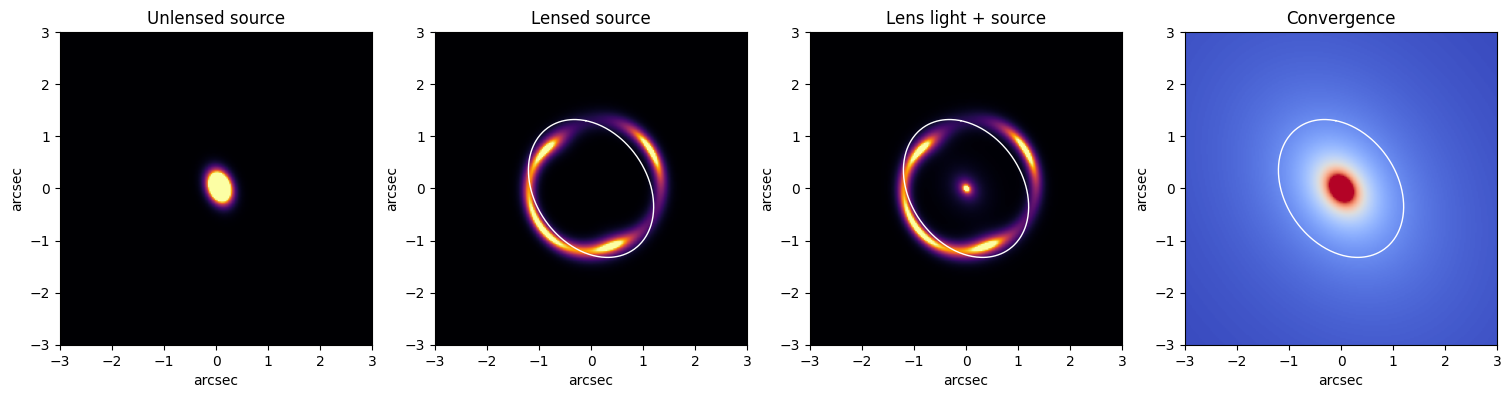

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
panels = [
    ("Unlensed source", source.image_unlensed, "inferno"),
    ("Lensed source", source.image, "inferno"),
    ("Lens light + source", total_image, "inferno"),
    ("Convergence", lens.ka, "coolwarm"),
]

for ax, (title, image, cmap) in zip(axes, panels):
    finite = image[np.isfinite(image)]
    vmax = np.percentile(finite, 99.5)
    ax.imshow(image, origin="lower", extent=extent, cmap=cmap, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("arcsec")
    ax.set_ylabel("arcsec")

for xcrit, ycrit in critical_lines:
    axes[1].plot(xcrit, ycrit, color="white", linewidth=1.0)
    axes[2].plot(xcrit, ycrit, color="white", linewidth=1.0)
    axes[3].plot(xcrit, ycrit, color="white", linewidth=1.0)



## Add a second mass component

Choose `second_lens_kind = "SIE"` or `"NFW"`, adjust the parameter dictionary for that component, and rerun this section. The original single-SIE lens above is left unchanged; the cells below build a composite lens and repeat the ray tracing.

In [ ]:
second_lens_kind = "SIE"  # choose "SIE" or "NFW", fare 2-3 casi per ciascuna per vedere come cambia la deflessione
second_lens_enabled = True

second_sie_kwargs = {
    "sigma0": 90.0, # cambiando qui diminuire, max 90
    "q": 0.9,
    "pa": np.deg2rad(-20.0),
    "theta_c": 1.0e-4,
    "x1": 1,
    "x2": -1,
}

second_nfw_kwargs = {
    "mass": 5.0e11, # cambiando qui diminuire, max 5.0e11
    "conc": 11.0,
    "q": 0.95,
    "pa": np.deg2rad(-20.0),
    "x1": 1,
    "x2": -1,
}

def build_second_lens(kind, enabled=True):
    if not enabled:
        return None

    kind = kind.upper()
    if kind == "SIE":
        return sie(co, zl=zl, zs=zs, **second_sie_kwargs)
    if kind == "NFW":
        return nfwell(co, zl=zl, zs=zs, **second_nfw_kwargs)

    raise ValueError('second_lens_kind must be either "SIE" or "NFW"')

second_lens = build_second_lens(second_lens_kind, second_lens_enabled)

if second_lens is None:
    lens_with_second = lens
    critical_lines_with_second = critical_lines
    print("Second mass component disabled; using the original SIE lens.")
else:
    second_lens.setGrid(theta=theta)
    lens_with_second = compositeModel(co, models=[lens, second_lens])
    lens_with_second.zl = zl
    lens_with_second.zs = zs
    lens_with_second.dl = lens.dl
    lens_with_second.ds = lens.ds
    lens_with_second.dls = lens.dls
    lens_with_second.setGrid(theta=theta)
    critical_lines_with_second = [lens_with_second.getCritPoints(cl) for cl in lens_with_second.tancl()]

    print(f"Added second {second_lens_kind.upper()} mass component at "
          f"({second_lens.x1:.2f}, {second_lens.x2:.2f}) arcsec")
    if second_lens_kind.upper() == "SIE":
        print(f"Second SIE Einstein radius: {second_lens.bsie():.3f} arcsec")
    else:
        print(f"Second NFW mass: {second_lens.mass:.2e} Msun")
        print(f"Second NFW concentration: {second_lens.conc:.2f}")
        print(f"Second NFW scale radius: {second_lens.rs_as:.3f} arcsec")

Added second SIE mass component at (1.00, -1.00) arcsec
Second SIE Einstein radius: 0.156 arcsec


## Ray trace with the composite lens

In [ ]:
source_with_second = sersic(
    size=fov,
    Npix=npix,
    gl=lens_with_second,
    save_unlensed=True,
    **source_kwargs,
)

total_image_with_second = source_with_second.image + lens_light.image

print(f"Composite-lens source flux sum: {source_with_second.image.sum():.3e}")
print(f"Change relative to original lens: "
      f"{source_with_second.image.sum() - source.image.sum():.3e}")

Composite-lens source flux sum: 1.805e+05
Change relative to original lens: -1.545e+04


## Visualize the composite-lens result

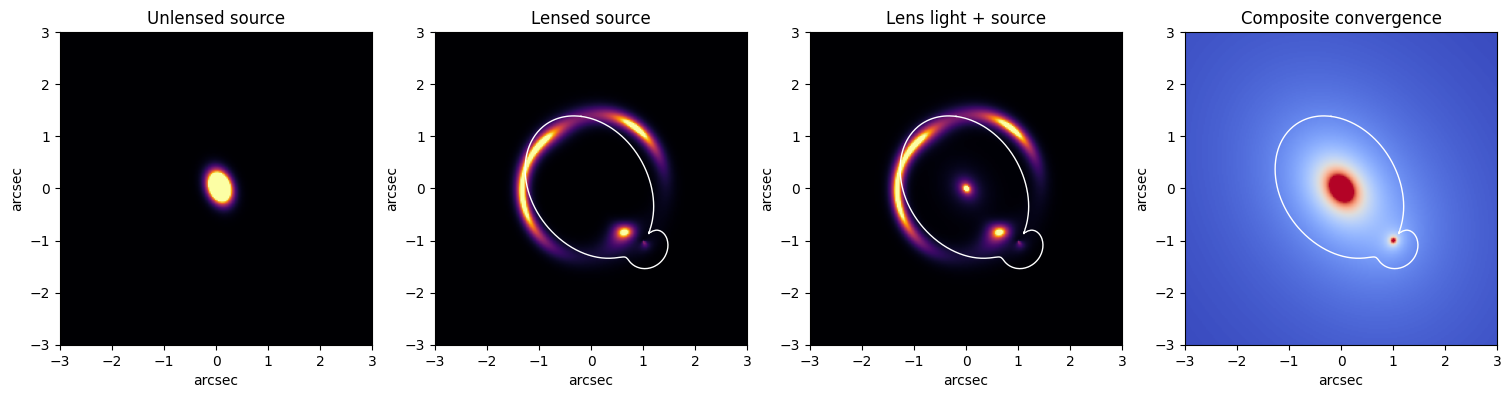

In [ ]:
fig_second, axes_second = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
panels_second = [
    ("Unlensed source", source_with_second.image_unlensed, "inferno"),
    ("Lensed source", source_with_second.image, "inferno"),
    ("Lens light + source", total_image_with_second, "inferno"),
    ("Composite convergence", lens_with_second.ka, "coolwarm"),
]

for ax, (title, image, cmap) in zip(axes_second, panels_second):
    finite = image[np.isfinite(image)]
    vmax = np.percentile(finite, 99.5)
    ax.imshow(image, origin="lower", extent=extent, cmap=cmap, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("arcsec")
    ax.set_ylabel("arcsec")

for xcrit, ycrit in critical_lines_with_second:
    axes_second[1].plot(xcrit, ycrit, color="white", linewidth=1.0)
    axes_second[2].plot(xcrit, ycrit, color="white", linewidth=1.0)
    axes_second[3].plot(xcrit, ycrit, color="white", linewidth=1.0)

# aggiungere cella per sottrarre immagini fra loro e vedere la posizione dei satelliti anche quando scompaiono dalle immagini 

## Save the composite-lens figure and arrays

In [ ]:
second_label = second_lens_kind.lower() if second_lens is not None else "none"
figure_path_second = outdir / f"first_lensing_simulation_second_{second_label}.png"
arrays_path_second = outdir / f"first_lensing_simulation_second_{second_label}.npz"

fig_second.savefig(figure_path_second, dpi=180)

np.savez_compressed(
    arrays_path_second,
    theta=theta,
    unlensed_source=source_with_second.image_unlensed,
    lensed_source=source_with_second.image,
    lens_light=lens_light.image,
    total_image=total_image_with_second,
    convergence=lens_with_second.ka,
    convergence_primary=lens.ka,
    convergence_second=second_lens.ka if second_lens is not None else np.zeros_like(lens.ka),
    alpha1=lens_with_second.a1,
    alpha2=lens_with_second.a2,
)

print(f"Saved {figure_path_second}")
print(f"Saved {arrays_path_second}")

Saved /home/sabrina-n/tesi-triennale/outputs/first_lensing_simulation_second_sie.png
Saved /home/sabrina-n/tesi-triennale/outputs/first_lensing_simulation_second_sie.npz


## Save the figure and arrays

In [ ]:
figure_path = outdir / "first_lensing_simulation.png"
arrays_path = outdir / "first_lensing_simulation.npz"

fig.savefig(figure_path, dpi=180)

np.savez_compressed(
    arrays_path,
    theta=theta,
    unlensed_source=source.image_unlensed,
    lensed_source=source.image,
    lens_light=lens_light.image,
    total_image=total_image,
    convergence=lens.ka,
)

print(f"Saved {figure_path}")
print(f"Saved {arrays_path}")

Saved /home/sabrina-n/tesi-triennale/outputs/first_lensing_simulation.png
Saved /home/sabrina-n/tesi-triennale/outputs/first_lensing_simulation.npz


## Quick numerical checks

In [ ]:
summary = {
    "einstein_radius_arcsec": lens.bsie(),
    "unlensed_source_sum": source.image_unlensed.sum(),
    "lensed_source_sum": source.image.sum(),
    "lens_light_sum": lens_light.image.sum(),
    "total_image_sum": total_image.sum(),
    "convergence_min": np.nanmin(lens.ka),
    "convergence_max": np.nanmax(lens.ka),
}

for name, value in summary.items():
    print(f"{name}: {value:.6e}")

einstein_radius_arcsec: 1.430377e+00
unlensed_source_sum: 9.996405e+03
lensed_source_sum: 1.958980e+05
lens_light_sum: 2.756428e+04
total_image_sum: 2.234623e+05
convergence_min: 1.272710e-01
convergence_max: 3.649110e+01


## Difference betweeen images to show residuals

Saved /home/sabrina-n/tesi-triennale/outputs/SIE_residuals.png
Saved /home/sabrina-n/tesi-triennale/outputs/SIE_residuals.npz


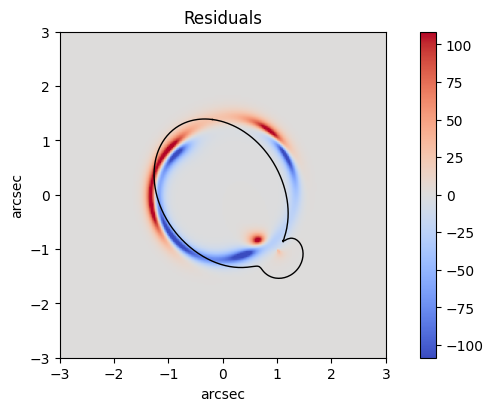

In [ ]:
difference = source_with_second.image - source.image
abs_difference = np.abs(difference)

fig_third, axes_third = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
panels_third = [
    ("Residuals", difference, "coolwarm")
]

vmax_abs = np.percentile(np.abs(difference), 99.5)

axes_third.set_title(title)
axes_third.set_xlabel("arcsec")
axes_third.set_ylabel("arcsec")


im1=axes_third.imshow(
    difference,
    origin="lower",
    extent=extent,
    cmap="coolwarm",
    vmin=-vmax_abs,
    vmax=vmax_abs
)

fig_third.colorbar(im1, ax=axes_third)

for xcrit, ycrit in critical_lines_with_second:
    axes_third.plot(xcrit, ycrit, color="black", linewidth=1.0)

# TEST
if not second_lens_enabled: 
    print(np.max(np.abs(difference)))

figure_path = outdir / f"{second_lens_kind}_residuals.png"
arrays_path = outdir / f"{second_lens_kind}_residuals.npz"

fig_third.savefig(figure_path, dpi=300, bbox_inches="tight")

np.savez_compressed(
    arrays_path,
    difference=difference,
    abs_difference=abs_difference,
)

print(f"Saved {figure_path}")
print(f"Saved {arrays_path}")

Total flux of residuals (percentage of tot flux image)

Percentuale del flusso del residuo rispetto al totale: 7.4256788512519325
Posizione del picco (in pixel): (np.int64(81), np.int64(75))
Posizione del picco (in arcsec): (np.float64(-0.945205479452055), np.float64(-0.7808219178082192))
Valore del picco: 180.41256626070088


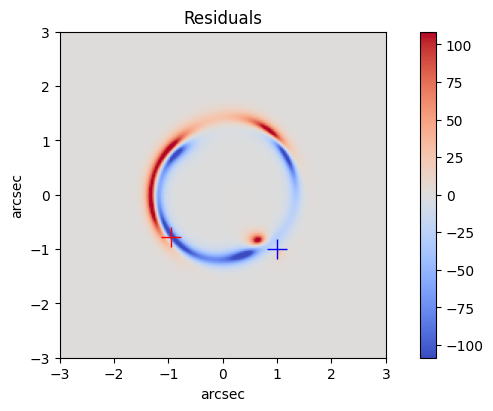

In [ ]:
def calculate_metrics(abs_difference, difference, total_image_with_second, theta):
 percentage = np.abs(difference.sum() / total_image_with_second.sum())*100
 peak_position_pixel = np.unravel_index(np.argmax(abs_difference), difference.shape)
 row_idx, col_idx = peak_position_pixel
 theta_y = theta[row_idx]
 theta_x = theta[col_idx]
 peak_position_arcsec = (theta_x, theta_y)
 peak_value = abs_difference.max()
 
 print(f"Percentuale del flusso del residuo rispetto al totale: {percentage}")
 print(f"Posizione del picco (in pixel): {peak_position_pixel}")
 print(f"Posizione del picco (in arcsec): {peak_position_arcsec}")
 print(f"Valore del picco: {peak_value}")
 return percentage, peak_position_pixel, peak_position_arcsec, peak_value, theta_x, theta_y

percentage, peak_position_pixel, peak_position_arcsec, peak_value, theta_x, theta_y = calculate_metrics(abs_difference, difference, total_image_with_second, theta)

axes_third.cla()  # clear axis: rimuove tutto quello che c'era prima
axes_third.imshow(difference, origin="lower", extent=extent, cmap="coolwarm",  vmin=-vmax_abs,
    vmax=vmax_abs)
axes_third.plot(theta_x, theta_y, 'r+', markersize=15)
axes_third.plot(second_lens.x1, second_lens.x2, 'b+', markersize=15)
axes_third.set_title("Residuals")
axes_third.set_xlabel("arcsec")
axes_third.set_ylabel("arcsec")
display(fig_third)
